# Optimal Transport based ICA versus FastICA - linear setting

### We compare the performance of OT based ICA and FastICA over varying number of dimensions and sample size of simulation with LBGFS optimization instead of SGD.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import FastICA
from tqdm.notebook import tqdm

# IMPORT YOUR PACKAGE
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Metrics & Simulation Helpers
# ==========================================

def amari_error(W_est, A_true):
    """
    Computes the Amari Performance Index.
    0.0 = Perfect recovery (up to permutation/scale).
    """
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
        
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    
    # Sum over rows
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    
    # Sum over cols
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    
    return (term1 + term2) / (2 * n)

In [3]:
def get_whitening_matrix(X_torch):
    """
    Helper to reconstruct the Whitening Matrix W_white used inside your class.
    We need this to calculate the Total Unmixing Matrix: W_total = W_sphere @ W_white
    """
    n_samples = X_torch.shape[1]
    X_centered = X_torch - torch.mean(X_torch, dim=1, keepdim=True)
    cov = torch.matmul(X_centered, X_centered.t()) / (n_samples - 1)
    D, E = torch.linalg.eigh(cov)
    D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D + 1e-5))
    W = torch.matmul(D_inv_sqrt, E.T)
    return W.cpu().numpy()

def generate_dataset(n_dim, n_samples, seed=None, dist_type='laplace'):
    """
    Generates mixed data where ALL sources come from the same distribution family.
    
    Parameters:
    -----------
    dist_type : str
        'laplace'   (Super-Gaussian, sharp peak) - Standard ICA Benchmark
        'uniform'   (Sub-Gaussian, flat)         - Hard for some algorithms
        'student-t' (Heavy-tailed, df=3)         - Good for robustness check
        'beta'      (U-shaped, bimodal-ish)      
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    sources = []
    for _ in range(n_dim):
        if dist_type == 'laplace':
            # Standard Laplace (Mean=0, Scale=1)
            s = np.random.laplace(0, 1, n_samples)
            
        elif dist_type == 'uniform':
            # Unit variance Uniform [-sqrt(3), sqrt(3)]
            s = np.random.uniform(-np.sqrt(3), np.sqrt(3), n_samples)
            
        elif dist_type == 'student-t':
            # Heavy tails (Degrees of Freedom = 3)
            s = np.random.standard_t(df=3, size=n_samples)
            
        elif dist_type == 'beta':
            # Beta(0.5, 0.5) is "Arcsine" (U-shaped)
            s = np.random.beta(0.5, 0.5, size=n_samples)
            s = (s - np.mean(s)) / np.std(s) # Normalize
            
        else:
            raise ValueError(f"Unknown dist_type: {dist_type}")
            
        sources.append(s)
        
    S = np.stack(sources)
    
    # Random Mixing Matrix with condition number check
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [4]:
# ==========================================
# 2. Experiment Configuration
# ==========================================

# --- Laptop Settings (Fast/Debug) ---
DIMENSION_RANGE = list(range(2, 31))      # Varying D
SAMPLE_SIZE_RANGE = [500, 1000, 5000] + list(range(10000, 100001, 5000)) # Varying N
N_TRIALS = 3                          # Repeats per point (for Error Bars)

# --- Cluster Settings---
# DIMENSION_RANGE = [2, 4, 8, 16, 32]
# SAMPLE_SIZE_RANGE = [500, 1000, 5000, 10000, 50000]
# N_TRIALS = 20

# Fixed Constants for the opposing experiment
FIXED_DIM = 6         # Used when varying Sample Size
FIXED_SAMPLES = 2000  # Used when varying Dimensions

print(f"--- Configuration ---")
print(f"Varying Dimensions: {DIMENSION_RANGE} (at N={FIXED_SAMPLES})")
print(f"Varying Samples:    {SAMPLE_SIZE_RANGE} (at D={FIXED_DIM})")
print(f"Trials per setting: {N_TRIALS}")

--- Configuration ---
Varying Dimensions: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30] (at N=2000)
Varying Samples:    [500, 1000, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000] (at D=6)
Trials per setting: 3


In [5]:
# ==========================================
# 3. Main Experiment Loop (L-BFGS Enabled)
# ==========================================
results = []

# --- Experiment A: Varying Dimensions ---
print("\nRunning Experiment 1: Varying Dimensions...")
for dim in tqdm(DIMENSION_RANGE, desc="Dimensions"):
    for trial in range(N_TRIALS):
        # 1. Data Gen
        X_torch, A_true = generate_dataset(n_dim=dim, n_samples=FIXED_SAMPLES, seed=trial, dist_type='laplace')
        X_np = X_torch.numpy()
        
        # 2. FastICA
        try:
            fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-3, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast = fast_ica.components_ 
            score_fast = amari_error(W_fast, A_true)
        except Exception as e:
            score_fast = np.nan
            
        # 3. WassersteinICA (Deflation + L-BFGS Refinement)
        try:
            ica = WassersteinICA(X_torch)
            ica.whiten()
            
            # --- PHASE 1: Deflationary Initialization (Rough Draft with SGD) ---
            extracted_ws = []
            for _ in range(dim):
                prev = torch.stack(extracted_ws) if extracted_ws else None
                w, _ = ica.optimize_wasserstein2(
                    prev_components=prev, 
                    max_iter=200, 
                    lr=0.1, 
                    continuous=True,
                    n_restarts=3
                )
                extracted_ws.append(w)
            
            W_deflation = torch.stack(extracted_ws)
            
            # --- PHASE 2: Symmetric Refinement (L-BFGS Polish) ---
            W_sphere = ica.optimize_symmetric(
                n_components=dim,
                init_w=W_deflation,
                max_iter=200,         # L-BFGS needs fewer iterations
                lr=1.0,              # Standard LR for L-BFGS
                optimizer='lbfgs',   # <--- ENABLE L-BFGS
                penalty_weight=10.0
            )
            
            # Reconstruct Total W
            W_white = get_whitening_matrix(X_torch) 
            W_wass = W_sphere.cpu().numpy() @ W_white
            
            score_wass = amari_error(W_wass, A_true)
        except Exception as e:
            print(f"Wasserstein Fail (Dim {dim}): {e}")
            score_wass = np.nan

        results.append({'Exp': 'Varying Dim', 'X': dim, 'N': FIXED_SAMPLES, 'Method': 'FastICA', 'Amari': score_fast})
        results.append({'Exp': 'Varying Dim', 'X': dim, 'N': FIXED_SAMPLES, 'Method': 'WassersteinICA', 'Amari': score_wass})


Running Experiment 1: Varying Dimensions...


Dimensions:   0%|          | 0/29 [00:00<?, ?it/s]

In [6]:
# --- Experiment B: Varying Sample Size ---
print("\nRunning Experiment 2: Varying Sample Size...")
for n in tqdm(SAMPLE_SIZE_RANGE, desc="Samples"):
    for trial in range(N_TRIALS):
        # 1. Data Gen
        X_torch, A_true = generate_dataset(n_dim=FIXED_DIM, n_samples=n, seed=trial + 1000, dist_type='laplace')
        X_np = X_torch.numpy()
        
        # 2. FastICA
        try:
            fast_ica = FastICA(n_components=FIXED_DIM, max_iter=2000, tol=1e-3, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast = fast_ica.components_ 
            score_fast = amari_error(W_fast, A_true)
        except:
            score_fast = np.nan
            
        # 3. WassersteinICA
        try:
            ica = WassersteinICA(X_torch)
            ica.whiten()
            
            # Phase 1
            extracted_ws = []
            for _ in range(FIXED_DIM):
                prev = torch.stack(extracted_ws) if extracted_ws else None
                w, _ = ica.optimize_wasserstein2(
                    prev_components=prev, 
                    max_iter=200, 
                    lr=0.1, 
                    continuous=True,
                    n_restarts=3
                )
                extracted_ws.append(w)
            
            W_deflation = torch.stack(extracted_ws)

            # Phase 2 (L-BFGS)
            W_sphere = ica.optimize_symmetric(
                n_components=FIXED_DIM,
                init_w=W_deflation,
                max_iter=200,
                lr=1.0,
                optimizer='lbfgs',
                penalty_weight=10.0
            )
            
            W_white = get_whitening_matrix(X_torch)
            W_wass = W_sphere.cpu().numpy() @ W_white
            
            score_wass = amari_error(W_wass, A_true)
        except Exception as e:
            print(f"Wasserstein Fail (N {n}): {e}")
            score_wass = np.nan

        results.append({'Exp': 'Varying N', 'X': n, 'N': n, 'Method': 'FastICA', 'Amari': score_fast})
        results.append({'Exp': 'Varying N', 'X': n, 'N': n, 'Method': 'WassersteinICA', 'Amari': score_wass})


Running Experiment 2: Varying Sample Size...


Samples:   0%|          | 0/22 [00:00<?, ?it/s]

In [7]:
df_results = pd.DataFrame(results)

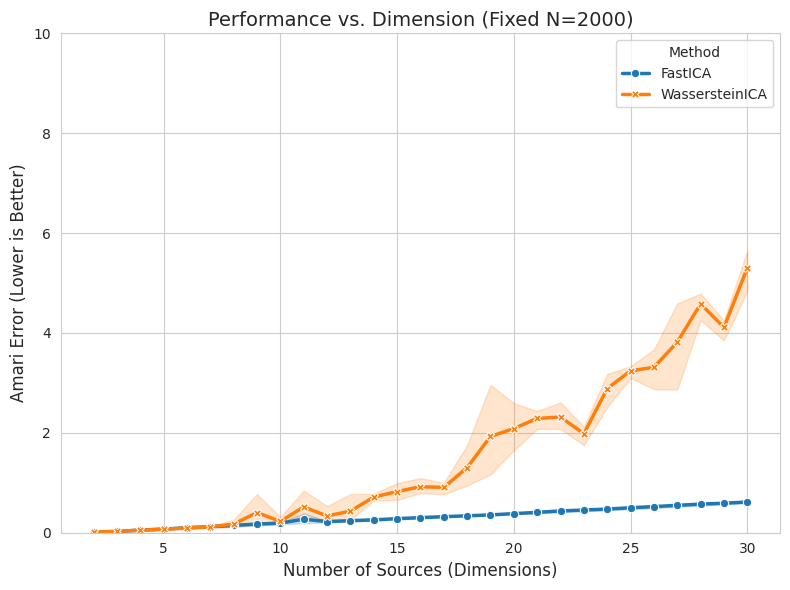


--- Summary Statistics (Varying Dimensions) ---


mean     std
X  Method                        
2  FastICA         0.0117  0.0050
   WassersteinICA  0.0118  0.0092
3  FastICA         0.0254  0.0122
   WassersteinICA  0.0283  0.0115
4  FastICA         0.0529  0.0085
   WassersteinICA  0.0504  0.0081
5  FastICA         0.0724  0.0137
   WassersteinICA  0.0689  0.0129
6  FastICA         0.1008  0.0219
   WassersteinICA  0.0977  0.0215
7  FastICA         0.1204  0.0186
   WassersteinICA  0.1165  0.0145
8  FastICA         0.1473  0.0189
   WassersteinICA  0.1747  0.0778
9  FastICA         0.1733  0.0288
   WassersteinICA  0.4038  0.3245
10 FastICA         0.1925  0.0166
   WassersteinICA  0.2256  0.0808
11 FastICA         0.2707  0.1096
   WassersteinICA  0.5164  0.2843
12 FastICA         0.2234  0.0154
   WassersteinICA  0.3358  0.1696
13 FastICA         0.2412  0.0167
   WassersteinICA  0.4323  0.2956
14 FastICA         0.2575  0.0164
   WassersteinICA  0.7144  0.0695
15 FastICA         0.2822  0.0128
   WassersteinICA  0.8241  0.1684
16 FastICA         0.3017  0.0139
   WassersteinICA  0.9214  0.1556
17 FastICA         0.3216  0.0122
   WassersteinICA  0.9072  0.1195
18 FastICA         0.3389  0.0113
   WassersteinICA  1.3040  0.4133
19 FastICA         0.3567  0.0126
   WassersteinICA  1.9275  0.9269
20 FastICA         0.3826  0.0158
   WassersteinICA  2.0867  0.4765
21 FastICA         0.4076  0.0203
   WassersteinICA  2.2877  0.1864
22 FastICA         0.4366  0.0242
   WassersteinICA  2.3174  0.2688
23 FastICA         0.4546  0.0230
   WassersteinICA  1.9824  0.2019
24 FastICA         0.4738  0.0219
   WassersteinICA  2.8865  0.3400
25 FastICA         0.5001  0.0259
   WassersteinICA  3.2415  0.1258
26 FastICA         0.5230  0.0277
   WassersteinICA  3.3129  0.4036
27 FastICA         0.5486  0.0249
   WassersteinICA  3.8162  0.8760
28 FastICA         0.5734  0.0284
   WassersteinICA  4.5813  0.2851
29 FastICA         0.5903  0.0162
   WassersteinICA  4.1116  0.2274
30 FastICA         0.6152  0.0220
   WassersteinICA  5.3021  0.4191

In [8]:
# ==========================================
# 4A. Plotting Results: Varying Dimensions
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# Filter Data for Dimensions Experiment
data_dim = df_results[df_results['Exp'] == 'Varying Dim']

# Plot
ax = sns.lineplot(
    data=data_dim, x='X', y='Amari', hue='Method', style='Method',
    markers=True, dashes=False, linewidth=2.5, errorbar=('ci', 95)
)

# Styling
plt.title(f"Performance vs. Dimension (Fixed N={FIXED_SAMPLES})", fontsize=14)
plt.xlabel("Number of Sources (Dimensions)", fontsize=12)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.ylim(0, 10.0)

plt.tight_layout()
plt.show()

# Display Statistics Table for Dimensions
print("\n--- Summary Statistics (Varying Dimensions) ---")
display(data_dim.groupby(['X', 'Method'])['Amari'].agg(['mean', 'std']).round(4))

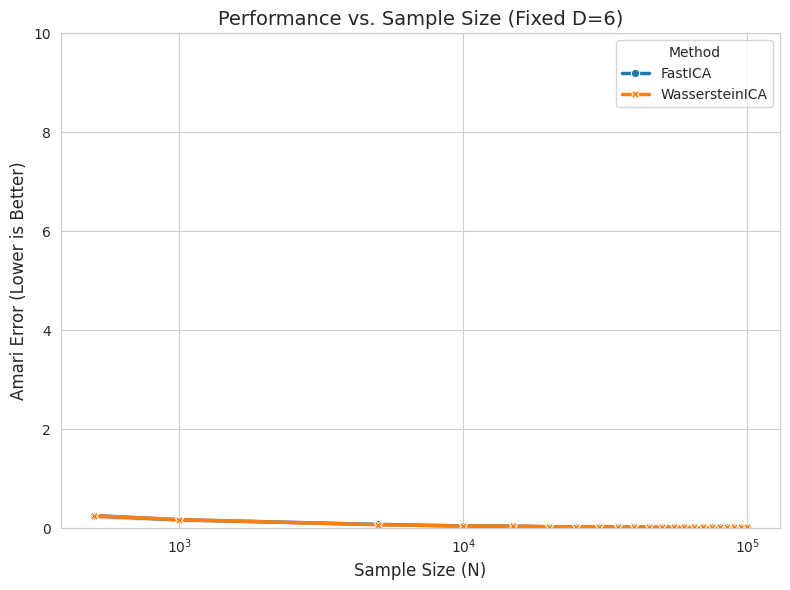


--- Summary Statistics (Varying Sample Size) ---


mean     std
X      Method                        
500    FastICA         0.2505  0.0270
       WassersteinICA  0.2504  0.0482
1000   FastICA         0.1695  0.0249
       WassersteinICA  0.1712  0.0191
5000   FastICA         0.0752  0.0117
       WassersteinICA  0.0698  0.0105
10000  FastICA         0.0435  0.0115
       WassersteinICA  0.0417  0.0110
15000  FastICA         0.0415  0.0016
       WassersteinICA  0.0406  0.0045
20000  FastICA         0.0271  0.0018
       WassersteinICA  0.0265  0.0027
25000  FastICA         0.0288  0.0040
       WassersteinICA  0.0272  0.0042
30000  FastICA         0.0290  0.0052
       WassersteinICA  0.0272  0.0045
35000  FastICA         0.0251  0.0055
       WassersteinICA  0.0233  0.0047
40000  FastICA         0.0228  0.0022
       WassersteinICA  0.0210  0.0014
45000  FastICA         0.0207  0.0019
       WassersteinICA  0.0195  0.0020
50000  FastICA         0.0203  0.0018
       WassersteinICA  0.0191  0.0018
55000  FastICA         0.0214  0.0011
       WassersteinICA  0.0223  0.0026
60000  FastICA         0.0163  0.0015
       WassersteinICA  0.0154  0.0008
65000  FastICA         0.0186  0.0017
       WassersteinICA  0.0182  0.0014
70000  FastICA         0.0182  0.0026
       WassersteinICA  0.0174  0.0020
75000  FastICA         0.0168  0.0006
       WassersteinICA  0.0163  0.0005
80000  FastICA         0.0163  0.0024
       WassersteinICA  0.0153  0.0019
85000  FastICA         0.0195  0.0040
       WassersteinICA  0.0187  0.0038
90000  FastICA         0.0167  0.0032
       WassersteinICA  0.0154  0.0025
95000  FastICA         0.0153  0.0013
       WassersteinICA  0.0143  0.0014
100000 FastICA         0.0138  0.0028
       WassersteinICA  0.0129  0.0030

In [9]:
# ==========================================
# 4B. Plotting Results: Varying Sample Size
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# Filter Data for Sample Size Experiment
data_n = df_results[df_results['Exp'] == 'Varying N']

# Plot
ax = sns.lineplot(
    data=data_n, x='X', y='Amari', hue='Method', style='Method',
    markers=True, dashes=False, linewidth=2.5, errorbar=('ci', 95)
)

# Styling
plt.title(f"Performance vs. Sample Size (Fixed D={FIXED_DIM})", fontsize=14)
plt.xlabel("Sample Size (N)", fontsize=12)
plt.xscale("log")  # Log scale is crucial for N
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.ylim(0, 10.0)

plt.tight_layout()
plt.show()

# Display Statistics Table for Sample Size
print("\n--- Summary Statistics (Varying Sample Size) ---")
display(data_n.groupby(['X', 'Method'])['Amari'].agg(['mean', 'std']).round(4))


--- Running Qualitative Check (Dim=10) ---


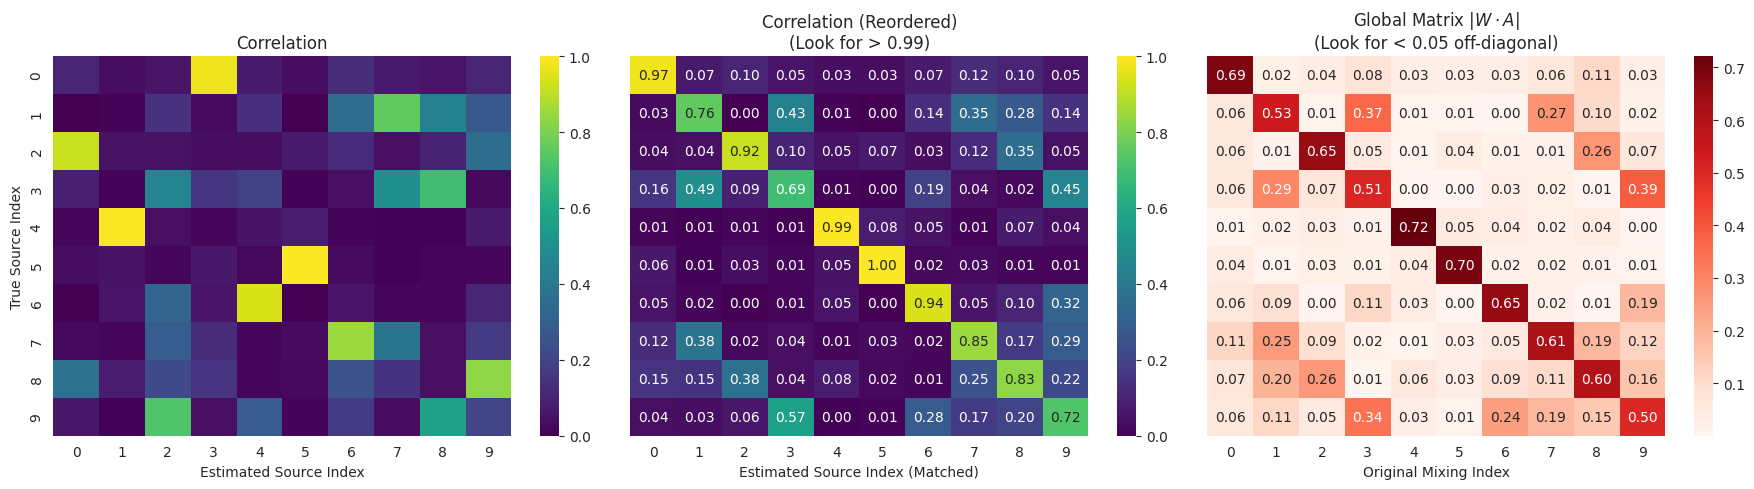

In [10]:
# ==========================================
# 5. Qualitative Analysis (L-BFGS Enabled)
# ==========================================
from scipy.optimize import linear_sum_assignment

def qualitative_check(n_dim=6, n_samples=2000):
    print(f"\n--- Running Qualitative Check (Dim={n_dim}) ---")
    
    # 1. Data Gen
    X_torch, A_true = generate_dataset(n_dim=n_dim, n_samples=n_samples, seed=42, dist_type='laplace')
    X_np = X_torch.numpy()
    S_true = np.linalg.inv(A_true) @ X_np
    
    # 2. Wasserstein ICA
    ica = WassersteinICA(X_torch)
    ica.whiten()
    
    # Phase 1
    extracted_ws = []
    for _ in range(n_dim):
        prev = torch.stack(extracted_ws) if extracted_ws else None
        w, _ = ica.optimize_wasserstein2(
            prev_components=prev, max_iter=200, lr=0.1, continuous=True, n_restarts=3
        )
        extracted_ws.append(w)
    W_deflation = torch.stack(extracted_ws)
    
    # Phase 2 (L-BFGS Polish)
    W_sphere = ica.optimize_symmetric(
        n_components=n_dim, 
        init_w=W_deflation, 
        max_iter=50, 
        lr=1.0, 
        optimizer='lbfgs', 
        penalty_weight=10.0
    )
    
    # Get Total W
    W_white = get_whitening_matrix(X_torch)
    W_est = W_sphere.cpu().numpy() @ W_white
    S_est = W_est @ X_np

    # 3. Match Sources
    corr_mat = np.zeros((n_dim, n_dim))
    for i in range(n_dim):
        for j in range(n_dim):
            corr_mat[i, j] = np.abs(np.corrcoef(S_true[i], S_est[j])[0, 1])
    
    row_ind, col_ind = linear_sum_assignment(-corr_mat)
    S_est_ordered = S_est[col_ind]
    corr_mat_ordered = corr_mat[:, col_ind]
    
    # 4. Global Matrix
    P = np.abs(W_est @ A_true)
    P_ordered = P[col_ind, :]

    # Visuals
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.heatmap(corr_mat, ax=axes[0], cmap="viridis", vmin=0, vmax=1, annot=False)
    axes[0].set_title("Correlation")
    axes[0].set_xlabel("Estimated Source Index")
    axes[0].set_ylabel("True Source Index")

    sns.heatmap(corr_mat_ordered, ax=axes[1], cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f")
    axes[1].set_title("Correlation (Reordered)\n(Look for > 0.99)")
    axes[1].set_xlabel("Estimated Source Index (Matched)")
    axes[1].set_yticks([])

    sns.heatmap(P_ordered, ax=axes[2], cmap="Reds", annot=True, fmt=".2f")
    axes[2].set_title("Global Matrix $|W \\cdot A|$\n(Look for < 0.05 off-diagonal)")
    axes[2].set_xlabel("Original Mixing Index")
    axes[2].set_yticks([])

    plt.tight_layout()
    plt.show()

qualitative_check(n_dim=10)